### Домашнее задание 3. Реализация простой Lambda-архитектуры хранилища (Iceberg / Nessie / ClickHouse).

В данной работе вам необходимо реализовать комплексный ETL-процесс. Ниже приложена его архитектурная схема (`Infra-flow.png`).
Для решения необходимо использовать знакомые вам инструменты:
1. Spark DataFrame API (batch + staging batch)
2. Apache Iceberg + Project Nessie — каталог и табличный формат поверх S3 warehouse
3. Serverless Kafka — шина событий (топик `tickets-topic`)
4. ClickHouse — потоковый контур (Kafka Engine / Materialized View)
5. S3 (MinIO-compatible) — warehouse-директории **Sources → Staging → Target**

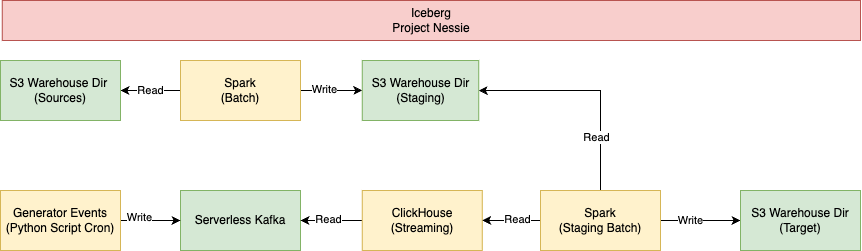

In [1]:

from pathlib import Path
from IPython.display import Image, Markdown, display

if Path("Infra-flow.png").exists():
    display(Image(filename="Infra-flow.png"))
else:
    display(Markdown("`Infra-flow.png` не найден рядом с ноутбуком; схема приложена отдельным файлом."))


#### Основные переменные и создание spark-сессии

In [2]:

# Параметры стенда.
# STUDENT_N восстановлен из прошлых Spark-заданий: student27.
# Kafka/ClickHouse: реквизиты из сообщения куратора для кластера 171.22.72.240.

STUDENT_N = "27"
STUDENT = f"student{STUDENT_N}"
NESSIE_CATALOG = "nessie"

KAFKA_BOOTSTRAP = "queue.mwsapis.ru:9093"
KAFKA_LOGIN = "admin"
KAFKA_PASSWORD = "E2|]b.iz28S~}1B9"
TICKETS_TOPIC = "tickets-topic"
KAFKA_GROUP = f"{STUDENT}_tickets_hw3"

CLICKHOUSE_HOST = "171.22.72.240"
CLICKHOUSE_LOGIN = "admin"
CLICKHOUSE_PASSWORD = "E2|]b.iz28S~}1B9"
CLICKHOUSE_DB = STUDENT

# На разных стендах ClickHouse может быть опубликован как HTTP:8123 или HTTPS:8443.
# Рабочий вариант будет найден автоматически в ячейке подключения и записан обратно
# в CLICKHOUSE_HOST / CLICKHOUSE_HTTP_PORT / CLICKHOUSE_SECURE.
CLICKHOUSE_HTTP_PORT = 8123
CLICKHOUSE_SECURE = False
CLICKHOUSE_CONNECT_CANDIDATES = [
    ("171.22.72.240", 8123, False),
    ("171.22.72.240", 8443, True),
    ("171.22.72.240", 8123, True),
    ("171.22.72.240", 8443, False),
    ("ch-vm-bolwad-sh1-r2-qacbexxah", 8123, False),
    ("ch-vm-bolwad-sh2-r1-qacbexxah", 8123, False),
]

ICEBERG_SOURCE_NS = "hw3_sources"
ICEBERG_USER_NS = STUDENT
CLICKHOUSE_CLUSTER = "bolwad"

# В учебном Jupyter Iceberg/Nessie обычно уже настроены в профиле Spark.
# Kafka читает ClickHouse, поэтому Spark Kafka package здесь не нужен.
# Если в окружении уже есть ClickHouse Spark connector, helpers ниже используют его;
# если нет, автоматически используется clickhouse_connect fallback.
JAVA_REQUIREMENTS = ""


In [3]:

import sys
import time
import subprocess

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql import Window


In [4]:

spark_builder = (
    SparkSession.builder
    .appName(f"hw3_user{STUDENT_N}")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.executor.cores", "2")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.sql.adaptive.enabled", "true")
)

if JAVA_REQUIREMENTS:
    spark_builder = spark_builder.config("spark.jars.packages", JAVA_REQUIREMENTS)

spark = spark_builder.getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
spark.sql("SELECT 1 AS spark_ok").show()
print("Spark version:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/05 15:05:57 WARN Utils: Your hostname, vm-en-2, resolves to a loopback address: 127.0.1.1; using 10.0.0.10 instead (on interface enp2s0)
26/09/05 15:05:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/09/05 15:05:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/05 15:05:58 WARN Utils: Service 'sparkDriver' could not bind on port 42700. Attempting port 42701.
26/09/05 15:05:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/09/05 15:05:59 WARN Utils: Service 'org.apache.spark.network.netty.NettyBlockTransferService' could not bind on port 42750. Att

+--------+
|spark_ok|
+--------+
|       1|
+--------+

Spark version: 4.1.1
Spark UI: http://10.0.0.10:4041


#### Примеры полезного кода

Для проверки корректности **в каждом блоке** (EDA, Speed, Batch, Serving) выводите:
1. план запроса (`explain`);
2. `count`;
3. несколько строк со **стабильной сортировкой**.

Используйте функцию `preview_df` из ячейки ниже. Без этих выводов блок считается неполным.

In [5]:

# ClickHouse: python-клиент нужен для DDL, контрольных запросов и вывода speed-слоя.
try:
    import clickhouse_connect
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "clickhouse-connect"])
    import clickhouse_connect


def create_clickhouse_client():
    global CLICKHOUSE_HOST, CLICKHOUSE_HTTP_PORT, CLICKHOUSE_SECURE

    errors = []
    for host, port, secure in CLICKHOUSE_CONNECT_CANDIDATES:
        try:
            client = clickhouse_connect.get_client(
                host=host,
                port=int(port),
                username=CLICKHOUSE_LOGIN,
                password=CLICKHOUSE_PASSWORD,
                secure=secure,
                connect_timeout=10,
                send_receive_timeout=30,
            )
            client.query("SELECT 1")
            CLICKHOUSE_HOST = host
            CLICKHOUSE_HTTP_PORT = int(port)
            CLICKHOUSE_SECURE = bool(secure)
            protocol = "https" if CLICKHOUSE_SECURE else "http"
            print(f"ClickHouse connected: {protocol}://{CLICKHOUSE_HOST}:{CLICKHOUSE_HTTP_PORT}")
            return client
        except Exception as exc:
            protocol = "https" if secure else "http"
            msg = f"{protocol}://{host}:{port} -> {type(exc).__name__}: {str(exc)[:300]}"
            print("Не подошёл вариант:", msg)
            errors.append(msg)

    raise RuntimeError(
        "Не удалось подключиться к ClickHouse ни одним из вариантов. "
        "Проверь пароль/адрес кластера и пришли полный текст последней ошибки.\n"
        + "\n".join(errors)
    )


ch = create_clickhouse_client()
ch.command(f"CREATE DATABASE IF NOT EXISTS {CLICKHOUSE_DB}")
print(ch.query("SELECT currentUser() AS user, currentDatabase() AS db").result_rows)


ClickHouse connected: http://171.22.72.240:8123
[('admin', 'default')]


In [6]:
# ClickHouse: landing-слой для чтения JSON-событий из Kafka.
# Kafka Engine читает каждое сообщение как raw JSON-строку, а MV парсит поля
# и сохраняет бизнес-данные вместе с Kafka timestamp в MergeTree-таблицу tickets.
#
# Важно для повторных прогонов: consumer group делаем уникальной и очищаем
# landing-таблицу. На этом кластере ClickHouse не поддерживает table setting
# чтения старых offsets из DDL, поэтому Kafka Engine читает live-поток; если генератор
# cron не публикует новые события во время запуска, speed-слой корректно останется
# пустым, а следующая ячейка выведет диагностику Kafka/ClickHouse.


def ch_exec(sql, echo=True):
    sql = sql.strip()
    if echo:
        print(sql)
        print()
    return ch.command(sql)


ch_exec(f"""
CREATE TABLE IF NOT EXISTS {CLICKHOUSE_DB}.tickets
(
    uuid String,
    number String,
    price Float64,
    currency_code LowCardinality(String),
    transaction_timestamp DateTime,
    kafka_timestamp DateTime,
    kafka_offset UInt64,
    kafka_partition UInt64,
    kafka_topic LowCardinality(String),
    ingest_timestamp DateTime DEFAULT now()
)
ENGINE = MergeTree
PARTITION BY toYYYYMMDD(transaction_timestamp)
ORDER BY (transaction_timestamp, number, uuid)
SETTINGS index_granularity = 8192
""")

# Перезапускаем потоковый landing-слой воспроизводимо: без дублей в tickets и с
# новой Kafka group. Таблицу revenue_5m пересоберём ниже в speed-ячейке.
ch_exec(f"DROP VIEW IF EXISTS {CLICKHOUSE_DB}.mv_tickets_kafka_to_tickets")
ch_exec(f"DROP TABLE IF EXISTS {CLICKHOUSE_DB}.tickets_kafka")
ch_exec(f"TRUNCATE TABLE {CLICKHOUSE_DB}.tickets")

effective_kafka_group = f"{KAFKA_GROUP}_{int(time.time())}"
print("Effective Kafka group:", effective_kafka_group)

ch_exec(f"""
CREATE TABLE {CLICKHOUSE_DB}.tickets_kafka
(
    raw_message String
)
ENGINE = Kafka
SETTINGS
    kafka_broker_list = '{KAFKA_BOOTSTRAP}',
    kafka_topic_list = '{TICKETS_TOPIC}',
    kafka_group_name = '{effective_kafka_group}',
    kafka_format = 'JSONAsString',
    kafka_num_consumers = 1,
    kafka_security_protocol = 'SASL_SSL',
    kafka_sasl_mechanism = 'PLAIN',
    kafka_sasl_username = '{KAFKA_LOGIN}',
    kafka_sasl_password = '{KAFKA_PASSWORD}',
    kafka_skip_broken_messages = 100
""")

mv_variants = [
    (
        "Raw JSON + Kafka virtual timestamp/offset/topic",
        f"""
CREATE MATERIALIZED VIEW {CLICKHOUSE_DB}.mv_tickets_kafka_to_tickets
TO {CLICKHOUSE_DB}.tickets
AS
SELECT
    uuid,
    number,
    parsed_price AS price,
    currency_code,
    parsed_transaction_timestamp AS transaction_timestamp,
    ifNull(toDateTime(_timestamp), now()) AS kafka_timestamp,
    toUInt64(_offset) AS kafka_offset,
    toUInt64(0) AS kafka_partition,
    toString(_topic) AS kafka_topic,
    now() AS ingest_timestamp
FROM
(
    SELECT
        nullIf(JSONExtractString(raw_message, 'uuid'), '') AS uuid,
        nullIf(JSONExtractString(raw_message, 'number'), '') AS number,
        coalesce(
            toFloat64OrNull(JSONExtractString(raw_message, 'price')),
            toFloat64OrNull(JSONExtractRaw(raw_message, 'price'))
        ) AS parsed_price,
        coalesce(
            nullIf(JSONExtractString(raw_message, 'currency_codes'), ''),
            nullIf(JSONExtractString(raw_message, 'currency_code'), '')
        ) AS currency_code,
        parseDateTimeBestEffortOrNull(
            coalesce(
                nullIf(JSONExtractString(raw_message, 'transaction_timestamp'), ''),
                nullIf(JSONExtractString(raw_message, 'timestamp'), '')
            )
        ) AS parsed_transaction_timestamp,
        _timestamp,
        _offset,
        _topic
    FROM {CLICKHOUSE_DB}.tickets_kafka
) AS src
WHERE
    uuid IS NOT NULL
    AND number IS NOT NULL
    AND currency_code IS NOT NULL
    AND parsed_price IS NOT NULL
    AND parsed_transaction_timestamp IS NOT NULL
""",
    ),
    (
        "Raw JSON + fallback without Kafka virtual columns",
        f"""
CREATE MATERIALIZED VIEW {CLICKHOUSE_DB}.mv_tickets_kafka_to_tickets
TO {CLICKHOUSE_DB}.tickets
AS
SELECT
    uuid,
    number,
    parsed_price AS price,
    currency_code,
    parsed_transaction_timestamp AS transaction_timestamp,
    now() AS kafka_timestamp,
    toUInt64(0) AS kafka_offset,
    toUInt64(0) AS kafka_partition,
    '{TICKETS_TOPIC}' AS kafka_topic,
    now() AS ingest_timestamp
FROM
(
    SELECT
        nullIf(JSONExtractString(raw_message, 'uuid'), '') AS uuid,
        nullIf(JSONExtractString(raw_message, 'number'), '') AS number,
        coalesce(
            toFloat64OrNull(JSONExtractString(raw_message, 'price')),
            toFloat64OrNull(JSONExtractRaw(raw_message, 'price'))
        ) AS parsed_price,
        coalesce(
            nullIf(JSONExtractString(raw_message, 'currency_codes'), ''),
            nullIf(JSONExtractString(raw_message, 'currency_code'), '')
        ) AS currency_code,
        parseDateTimeBestEffortOrNull(
            coalesce(
                nullIf(JSONExtractString(raw_message, 'transaction_timestamp'), ''),
                nullIf(JSONExtractString(raw_message, 'timestamp'), '')
            )
        ) AS parsed_transaction_timestamp
    FROM {CLICKHOUSE_DB}.tickets_kafka
) AS src
WHERE
    uuid IS NOT NULL
    AND number IS NOT NULL
    AND currency_code IS NOT NULL
    AND parsed_price IS NOT NULL
    AND parsed_transaction_timestamp IS NOT NULL
""",
    ),
]

last_mv_error = None
for mv_name, mv_sql in mv_variants:
    try:
        print("Trying MV variant:", mv_name)
        ch_exec(mv_sql)
        print("Created MV variant:", mv_name)
        break
    except Exception as exc:
        last_mv_error = exc
        print("MV variant failed:", mv_name)
        print(type(exc).__name__, str(exc)[:1200])
        ch_exec(f"DROP VIEW IF EXISTS {CLICKHOUSE_DB}.mv_tickets_kafka_to_tickets", echo=False)
else:
    raise last_mv_error

print(ch.query(f"SELECT count() AS tickets_rows FROM {CLICKHOUSE_DB}.tickets").result_rows)


CREATE TABLE IF NOT EXISTS student27.tickets
(
    uuid String,
    number String,
    price Float64,
    currency_code LowCardinality(String),
    transaction_timestamp DateTime,
    kafka_timestamp DateTime,
    kafka_offset UInt64,
    kafka_partition UInt64,
    kafka_topic LowCardinality(String),
    ingest_timestamp DateTime DEFAULT now()
)
ENGINE = MergeTree
PARTITION BY toYYYYMMDD(transaction_timestamp)
ORDER BY (transaction_timestamp, number, uuid)
SETTINGS index_granularity = 8192

DROP VIEW IF EXISTS student27.mv_tickets_kafka_to_tickets

DROP TABLE IF EXISTS student27.tickets_kafka

TRUNCATE TABLE student27.tickets

Effective Kafka group: student27_tickets_hw3_1788609966
CREATE TABLE student27.tickets_kafka
(
    raw_message String
)
ENGINE = Kafka
SETTINGS
    kafka_broker_list = 'queue.mwsapis.ru:9093',
    kafka_topic_list = 'tickets-topic',
    kafka_group_name = 'student27_tickets_hw3_1788609966',
    kafka_format = 'JSONAsString',
    kafka_num_consumers = 1,
    kafk

In [7]:

# Spark: чтение Iceberg Sources и ClickHouse landing table.

spark.sql(f"CREATE NAMESPACE IF NOT EXISTS {NESSIE_CATALOG}.{ICEBERG_USER_NS}")
spark.sql(f"SHOW NAMESPACES IN {NESSIE_CATALOG}").show(100, truncate=False)

flights_df = spark.table(f"{NESSIE_CATALOG}.{ICEBERG_SOURCE_NS}.flights")
currency_df = spark.table(f"{NESSIE_CATALOG}.{ICEBERG_SOURCE_NS}.currency")


def _unwrap_clickhouse_type(ch_type):
    t = ch_type.strip()
    changed = True
    while changed:
        changed = False
        for prefix in ("Nullable(", "LowCardinality("):
            if t.startswith(prefix) and t.endswith(")"):
                t = t[len(prefix):-1].strip()
                changed = True
    return t


def _spark_type_from_clickhouse(ch_type):
    t = _unwrap_clickhouse_type(ch_type)
    if t.startswith("DateTime"):
        return T.TimestampType()
    if t == "Date":
        return T.DateType()
    if t.startswith(("Float", "Decimal")):
        return T.DoubleType()
    if t.startswith(("UInt", "Int")):
        return T.LongType()
    if t == "Bool":
        return T.BooleanType()
    return T.StringType()


def _clickhouse_describe(table_name):
    return ch.query(f"DESCRIBE TABLE {CLICKHOUSE_DB}.{table_name}").result_rows


def _clickhouse_schema(table_name):
    return T.StructType([
        T.StructField(name, _spark_type_from_clickhouse(ch_type), True)
        for name, ch_type, *_ in _clickhouse_describe(table_name)
    ])


def _clickhouse_columns(table_name):
    return [name for name, *_ in _clickhouse_describe(table_name)]


def read_clickhouse_table(table_name):
    """Читаем ClickHouse без Spark connector и без pandas."""
    print(f"Reading ClickHouse table {CLICKHOUSE_DB}.{table_name} via clickhouse_connect")
    schema = _clickhouse_schema(table_name)
    rows = ch.query(f"SELECT * FROM {CLICKHOUSE_DB}.{table_name}").result_rows
    return spark.createDataFrame(rows, schema=schema)


def write_clickhouse_table(df, table_name, mode="append"):
    """Пишем в ClickHouse без Spark connector и без pandas."""
    if mode == "overwrite":
        ch.command(f"TRUNCATE TABLE {CLICKHOUSE_DB}.{table_name}")
    rows_count = df.count()
    if rows_count == 0:
        print(f"{table_name}: DataFrame пустой, вставлять нечего.")
        return
    column_names = df.columns
    rows = [tuple(row[col] for col in column_names) for row in df.collect()]
    print(f"Writing {rows_count} rows to ClickHouse table {CLICKHOUSE_DB}.{table_name} via clickhouse_connect")
    ch.insert(table_name, rows, column_names=column_names, database=CLICKHOUSE_DB)


tickets_ch_df = read_clickhouse_table("tickets")


+-------------+
|namespace    |
+-------------+
|lesson3_test |
|student28    |
|student29    |
|studentX     |
|student30    |
|student15    |
|student16    |
|student38    |
|student13    |
|student35    |
|student14    |
|student36    |
|student11    |
|student33    |
|student12    |
|student34    |
|lesson3      |
|student10    |
|student32    |
|lesson3_1    |
|student1     |
|student19    |
|hw3_sources  |
|student17    |
|student3     |
|student39    |
|student18    |
|student2     |
|student5     |
|student4     |
|student40    |
|student41    |
|yb_test1     |
|student26    |
|student27    |
|test_from_st4|
|student24    |
|student46    |
|student25    |
|student22    |
|student23    |
|student45    |
|student20    |
|student42    |
|student21    |
|student43    |
+-------------+



SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


Reading ClickHouse table student27.tickets via clickhouse_connect


In [8]:
def preview_df(df, title, order_by, n=15):
    """План запроса + count + стабильно отсортированный sample."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print("--- schema ---")
    df.printSchema()
    print("--- explain ---")
    df.explain()
    cnt = df.count()
    print(f"--- count = {cnt} ---")
    cols = order_by if isinstance(order_by, (list, tuple)) else [order_by]
    print(f"--- show({n}) ORDER BY {', '.join(str(c) for c in cols)} ---")
    df.orderBy(*cols).show(n, truncate=False)
    return cnt


def save_iceberg_table(df, table_name, mode="replace"):
    full_name = f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.{table_name}"
    print(f"Saving {full_name}")
    writer = df.writeTo(full_name).using("iceberg")
    if mode == "replace":
        writer.createOrReplace()
    else:
        writer.append()
    print(f"Saved {full_name}")
    spark.table(full_name).show(10, truncate=False)
    return full_name


def floor_to_15m(col_name):
    return (
        F.from_unixtime((F.unix_timestamp(F.col(col_name)) / F.lit(900)).cast("long") * 900)
        .cast("timestamp")
    )


preview_df(flights_df, "flights (Sources)", ["number", "departure_time"], n=5)
preview_df(currency_df, "currency (Sources)", ["timestamp", "target_currency"], n=5)
preview_df(tickets_ch_df, "tickets (ClickHouse landing)", ["kafka_timestamp", "uuid"], n=5)


flights (Sources)
--- schema ---
root
 |-- number: string (nullable = true)
 |-- departure: string (nullable = true)
 |-- arrival: string (nullable = true)
 |-- departure_time: timestamp (nullable = true)
 |-- arrival_time: timestamp (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- model: string (nullable = true)
 |-- capacity: integer (nullable = true)
 |-- luggage_allowed: string (nullable = true)
 |-- meal_included: string (nullable = true)

--- explain ---
== Physical Plan ==
*(1) ColumnarToRow
+- BatchScan nessie.hw3_sources.flights[number#10, departure#11, arrival#12, departure_time#13, arrival_time#14, manufacturer#15, model#16, capacity#17, luggage_allowed#18, meal_included#19] IcebergScan(table=nessie.hw3_sources.flights, schemaId=0, snapshotId=4226540285640171586, branch=null, filters=, runtimeFilters=, groupedBy=) RuntimeFilters: []


--- count = 237180 ---
--- show(5) ORDER BY number, departure_time ---


+------+--------------+-----------------+-------------------+-------------------+------------+------------------+--------+---------------+-------------+
|number|departure     |arrival          |departure_time     |arrival_time       |manufacturer|model             |capacity|luggage_allowed|meal_included|
+------+--------------+-----------------+-------------------+-------------------+------------+------------------+--------+---------------+-------------+
|BE1000|South Julieton|North Racheltown |2022-05-24 06:16:00|2022-05-24 22:16:00|Bombardier  |Bombardier CRJ700 |177     |no             |no           |
|BE1000|North Victor  |Bradburgh        |2022-06-30 16:53:00|2022-07-01 11:53:00|Boeing      |Boeing 707        |215     |no             |yes          |
|BE1000|South Laura   |Bennettmouth     |2022-10-02 04:24:00|2022-10-03 00:24:00|Airbus      |Airbus A220       |215     |no             |no           |
|BE1000|Reginaldstad  |Lake Bridgetshire|2023-05-06 14:13:00|2023-05-07 08:13:00|B

+-------------------+-------------+---------------+------+
|timestamp          |base_currency|target_currency|price |
+-------------------+-------------+---------------+------+
|2024-06-18 00:00:00|USD          |BMD            |0.9806|
|2024-06-18 00:00:00|USD          |BND            |1.0279|
|2024-06-18 00:00:00|USD          |BZD            |1.0287|
|2024-06-18 00:00:00|USD          |CLP            |0.9886|
|2024-06-18 00:00:00|USD          |COP            |1.0343|
+-------------------+-------------+---------------+------+
only showing top 5 rows

tickets (ClickHouse landing)
--- schema ---
root
 |-- uuid: string (nullable = true)
 |-- number: string (nullable = true)
 |-- price: double (nullable = true)
 |-- currency_code: string (nullable = true)
 |-- transaction_timestamp: timestamp (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- kafka_offset: long (nullable = true)
 |-- kafka_partition: long (nullable = true)
 |-- kafka_topic: string (nullable = true)
 |-

--- count = 0 ---
--- show(5) ORDER BY kafka_timestamp, uuid ---
+----+------+-----+-------------+---------------------+---------------+------------+---------------+-----------+----------------+
|uuid|number|price|currency_code|transaction_timestamp|kafka_timestamp|kafka_offset|kafka_partition|kafka_topic|ingest_timestamp|
+----+------+-----+-------------+---------------------+---------------+------------+---------------+-----------+----------------+
+----+------+-----+-------------+---------------------+---------------+------------+---------------+-----------+----------------+



0

### Что нужно сделать?

**1. Разведочный анализ (EDA) имеющихся данных**

Данные интеграции были настроены вашим коллегами из внешней для вас системы.

Необходимо рассмотреть:
- Iceberg-таблицы в Nessie-схеме `hw3_sources` (слой **Sources**);
- топик Kafka `tickets-topic` (через ClickHouse Kafka Engine и/или выборку из landing-таблицы);
- при необходимости — как данные физически лежат в S3 warehouse.

Описать, какие проблемы с данными и/или их хранением существуют (если есть). Предложить возможные решения.

**Вывод результатов:** для каждого исследуемого датафрейма вызвать `preview_df` (план, `count`, отсортированный sample).

In [9]:
# Блок 1 дублируется ниже в рабочем разделе после описания данных.
# Здесь оставлен маркер, чтобы структура исходного шаблона не терялась.

**2. Обработка near realtime потока данных tickets**

Контур: **Generator (cron) → Serverless Kafka → ClickHouse (Streaming) → Spark (обогащение справочником)**.

Для ingest использовать ClickHouse (не Spark Structured Streaming). Join со справочником валют и расчёт выручки — в Spark.

2.1. Настроить чтение данных с приведением стоимости проданных билетов к **базовой валюте**. Информацию о курсе возьмите из справочника **currency** (Iceberg Sources).

2.2. Подсчитать отставание данных:
- для сравнения использовать timestamp из топика Kafka (виртуальная колонка ClickHouse Kafka Engine);
- отставание выражено в сутках;
- исключить данные глубиной больше **1 дня**.

2.3. Реализовать трансформацию:
- выручка каждой авиакомпании за поступающее окно;
- размер окна — 5 минут.

**Важно**:
- все дробные данные должны округляться до сотых;
- промежуточный/скоростной результат сохранить в ClickHouse (БД `student{n}`, таблицы создать самостоятельно);
- результат (топ-10 строк) также обязательно выводится в ячейку запросом через python-клиент ClickHouse (не через Spark);
- **до записи** и по ключевым промежуточным DF вызвать `preview_df` (план, `count`, отсортированный sample).

In [10]:
# Блок 2 дублируется ниже в рабочем разделе после описания данных.

**3. Батчевая обработка сырых данных. Таблица flights**

Spark (Batch) читает слой **Sources**, пишет отчёты в слой **Staging** (Iceberg / Nessie namespace `student{n}`).

3.1. В какие города летают авиакомпании?:
- Сформировать список городов
- Посчитать их количество

3.2. Построить отчет по авиапарку компаний за 2024-2025 года:
- для каждой компании подсчитайте количество самолетов каждой категории
- совокупную вместимость за год (максимальное количество, которое можно перевести за год)
- среднюю вместимость
- допущение: 1 рейс = 1 самолет (они не чередуются между рейсами)

3.3. Найти топ-5 авиакомпаний с наименьшим средним временем полета:
- реализовать описанную трансформацию
- учесть проведенный в п.1 EDA

3.4. Построить отчет по количеству перевезенных пассажиров за каждый квартал доступных лет (ориентир — 2024 и 2025):
- сколько пассажиров авиакомпании могут перевезти за конкретный квартал в разрезе каждой компании
- посчитать изменение в процентах от квартала к кварталу (необходимо использовать оконные функции)
- провести сортировку по количеству пассажиров по убыванию

**(!)** Две из 4-х таблиц необходимы для реализации блока #4 (нужно понять какие)

**Важно**:
- все дробные данные должны округляться до сотых;
- результаты сохранить в отдельные Iceberg-таблицы слоя **Staging** (`nessie.student{n}.*`);
- каждый отчёт вывести через `preview_df` (план, `count`, отсортированный sample). Для 3.4 сортировка sample — по убыванию пассажиров.

In [11]:
# Блок 3 дублируется ниже в рабочем разделе после описания данных.

**4. Реализация serving layer в Target (Iceberg) + ClickHouse**

Spark (Staging Batch) читает **Staging** и **ClickHouse (Streaming)** и пишет слой **Target**.

4.1. Спроектировать модель данных и создать Iceberg-таблицы Target для сохранения результатов из блоков 2 и 3 (всего должно быть 3 таблицы).

4.2. Реализовать сборку serving-слоя в режиме batch: Staging (отчёты) + ClickHouse (выручка) → Target. Запускается 1 раз.

4.3. Выполнить запрос, отвечающий на вопрос (от потенциального сервиса): `Сможет ли конкретная авиакомпания отправить меня в конкретный город?`

4.4. Выполнить запрос, отвечающий на вопрос: `Сможет ли конкретная авиакомпания перевезти N пассажиров на основе данных за последний доступный отчётный квартальный период?`

4.5. Выполнить запрос, отвечающий на вопрос (на основе доступных данных): `Какая текущая выручка у конкретной компании за 2024 год?`

**Важно**:
- рассмотреть особенности партиционирования Iceberg, namespace/branch в Nessie и сортировочных ключей MergeTree в ClickHouse; описать, если учли;
- результат п.4.3–4.5 должен быть выведен в ячейку;
- запрос 4.5 допустимо выполнять python-клиентом к ClickHouse, если выручка остаётся в speed-слое; 4.3–4.4 — к таблицам Target;
- таблицы Target и ответы 4.3–4.5 вывести через `preview_df` (план, `count`, отсортированный sample).

**Как повысить оценку?**: при необходимости/просьба дать текстовые пояснения — оформляйте их в отдельных ячейках в виде Markdown-разметки. Больше пояснений о принятых решениях — дополнительные баллы к оценке.

Не забудьте `preview_df` в каждом блоке: без плана/`count`/отсортированного sample проверить ответ нельзя.

In [12]:
# Блок 4 дублируется ниже в рабочем разделе после описания данных.

### Описание данных

**1. flights** — Iceberg-таблица слоя Sources (схема `hw3_sources` в Nessie), содержит информацию об исторических рейсах различных авиакомпаний:
- number: номер рейса
- departure: город отправления
- arrival: город прибытия
- departure_time: время отправления
- arrival_time: время прибытия
- manufacturer: производитель самолета
- model: модель самолета
- capacity: вместимость пассажиров
- luggage_allowed: разрешен ли багаж (значения "yes" или "no")
- meal_included: включено ли питание (значения "yes" или "no")

**Важно**: идентификатор авиакомпании — первые ДВЕ буквы из номера рейса


**2. currency** — справочник, Iceberg-таблица слоя Sources (схема `hw3_sources`), содержит информацию о курсах валют каждые 15 минут:
- timestamp: временная метка
- base_currency: базовая валюта
- target_currency: целевая валюта
- price: цена целевой валюты по отношению к базовой валюте

**Важно**: базовая валюта — USD (американский доллар)

**3. tickets** — топик `tickets-topic` в Serverless Kafka (генератор — Python-скрипт по cron). ClickHouse читает топик напрямую. Содержит информацию о покупках билетов в онлайн-системе:
- uuid: уникальный идентификатор совершенной операции
- number: номер рейса, на который был куплен билет
- price: цена билета
- currency_codes: валюта, за которую был куплен билет
- transaction_timestamp: время совершения операции

Схема взаимодействия с данными (Sources → Staging → Target, Kafka → ClickHouse):

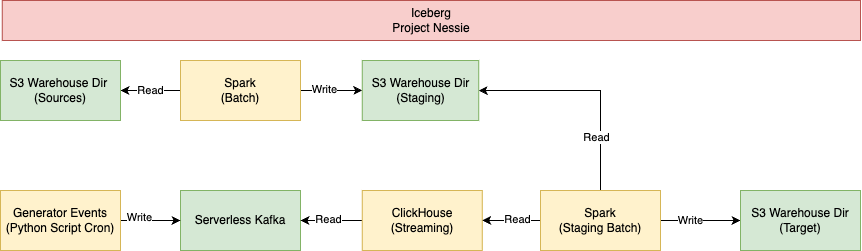

In [13]:

from pathlib import Path
from IPython.display import Image, Markdown, display

if Path("Infra-flow.png").exists():
    display(Image(filename="Infra-flow.png"))
else:
    display(Markdown("`Infra-flow.png` не найден рядом с ноутбуком; схема приложена отдельным файлом."))


### Решение

#### 1. EDA

In [14]:

# 1. Разведочный анализ Sources и landing-таблицы tickets.

flights_profile = (
    flights_df
    .withColumn("airline", F.substring("number", 1, 2))
    .withColumn("departure_ts", F.expr("try_cast(departure_time as TIMESTAMP)"))
    .withColumn("arrival_ts", F.expr("try_cast(arrival_time as TIMESTAMP)"))
    .withColumn("capacity_num", F.expr("try_cast(capacity as BIGINT)"))
    .agg(
        F.count("*").alias("rows"),
        F.countDistinct("number").alias("distinct_flight_numbers"),
        F.countDistinct("airline").alias("airlines"),
        F.countDistinct("departure").alias("departure_cities"),
        F.countDistinct("arrival").alias("arrival_cities"),
        F.min("departure_ts").alias("min_departure_time"),
        F.max("departure_ts").alias("max_departure_time"),
        F.sum(F.col("number").isNull().cast("int")).alias("null_numbers"),
        F.sum(F.col("capacity").isNull().cast("int")).alias("null_capacity"),
        F.sum((F.col("capacity").isNotNull() & F.col("capacity_num").isNull()).cast("int")).alias("bad_capacity"),
        F.sum((F.col("capacity_num") <= 0).cast("int")).alias("non_positive_capacity"),
    )
    .withColumn("dataset", F.lit("flights"))
    .select(
        "dataset", "rows", "distinct_flight_numbers", "airlines",
        "departure_cities", "arrival_cities", "min_departure_time",
        "max_departure_time", "null_numbers", "null_capacity",
        "bad_capacity", "non_positive_capacity",
    )
)

currency_profile = (
    currency_df
    .withColumn("rate_ts", F.expr("try_cast(timestamp as TIMESTAMP)"))
    .withColumn("price_num", F.expr("try_cast(price as DOUBLE)"))
    .agg(
        F.count("*").alias("rows"),
        F.countDistinct("target_currency").alias("target_currencies"),
        F.min("rate_ts").alias("min_rate_ts"),
        F.max("rate_ts").alias("max_rate_ts"),
        F.sum(F.col("price").isNull().cast("int")).alias("null_price"),
        F.sum((F.col("price").isNotNull() & F.col("price_num").isNull()).cast("int")).alias("bad_price"),
        F.sum((F.col("price_num") <= 0).cast("int")).alias("non_positive_price"),
    )
    .withColumn("dataset", F.lit("currency"))
    .select(
        "dataset", "rows", "target_currencies", "min_rate_ts",
        "max_rate_ts", "null_price", "bad_price", "non_positive_price",
    )
)

tickets_profile = (
    tickets_ch_df
    .withColumn("ticket_price_num", F.expr("try_cast(price as DOUBLE)"))
    .agg(
        F.count("*").alias("rows"),
        F.countDistinct("uuid").alias("distinct_uuid"),
        F.countDistinct(F.substring("number", 1, 2)).alias("airlines"),
        F.min("transaction_timestamp").alias("min_transaction_ts"),
        F.max("transaction_timestamp").alias("max_transaction_ts"),
        F.min("kafka_timestamp").alias("min_kafka_ts"),
        F.max("kafka_timestamp").alias("max_kafka_ts"),
        F.sum(F.col("uuid").isNull().cast("int")).alias("null_uuid"),
        F.sum(F.col("price").isNull().cast("int")).alias("null_price"),
        F.sum((F.col("price").isNotNull() & F.col("ticket_price_num").isNull()).cast("int")).alias("bad_price"),
    )
    .withColumn("dataset", F.lit("tickets"))
    .select(
        "dataset", "rows", "distinct_uuid", "airlines",
        "min_transaction_ts", "max_transaction_ts", "min_kafka_ts",
        "max_kafka_ts", "null_uuid", "null_price", "bad_price",
    )
)

preview_df(flights_df, "EDA: flights raw sample", ["number", "departure_time"], n=10)
preview_df(currency_df, "EDA: currency raw sample", ["timestamp", "target_currency"], n=10)
preview_df(tickets_ch_df, "EDA: tickets ClickHouse sample", ["kafka_timestamp", "uuid"], n=10)

preview_df(flights_profile, "EDA: flights profile", ["dataset"], n=5)
preview_df(currency_profile, "EDA: currency profile", ["dataset"], n=5)
preview_df(tickets_profile, "EDA: tickets profile", ["dataset"], n=5)



EDA: flights raw sample
--- schema ---
root
 |-- number: string (nullable = true)
 |-- departure: string (nullable = true)
 |-- arrival: string (nullable = true)
 |-- departure_time: timestamp (nullable = true)
 |-- arrival_time: timestamp (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- model: string (nullable = true)
 |-- capacity: integer (nullable = true)
 |-- luggage_allowed: string (nullable = true)
 |-- meal_included: string (nullable = true)

--- explain ---
== Physical Plan ==
*(1) ColumnarToRow
+- BatchScan nessie.hw3_sources.flights[number#10, departure#11, arrival#12, departure_time#13, arrival_time#14, manufacturer#15, model#16, capacity#17, luggage_allowed#18, meal_included#19] IcebergScan(table=nessie.hw3_sources.flights, schemaId=0, snapshotId=4226540285640171586, branch=null, filters=, runtimeFilters=, groupedBy=) RuntimeFilters: []


--- count = 237180 ---
--- show(10) ORDER BY number, departure_time ---
+------+---------------+-----------------+---

+-------------------+-------------+---------------+------+
|timestamp          |base_currency|target_currency|price |
+-------------------+-------------+---------------+------+
|2024-06-18 00:00:00|USD          |BMD            |0.9806|
|2024-06-18 00:00:00|USD          |BND            |1.0279|
|2024-06-18 00:00:00|USD          |BZD            |1.0287|
|2024-06-18 00:00:00|USD          |CLP            |0.9886|
|2024-06-18 00:00:00|USD          |COP            |1.0343|
|2024-06-18 00:00:00|USD          |CUC            |1.0369|
|2024-06-18 00:00:00|USD          |DZD            |1.0055|
|2024-06-18 00:00:00|USD          |EUR            |0.9749|
|2024-06-18 00:00:00|USD          |GEL            |1.0043|
|2024-06-18 00:00:00|USD          |GGP            |1.0095|
+-------------------+-------------+---------------+------+
only showing top 10 rows

EDA: tickets ClickHouse sample
--- schema ---
root
 |-- uuid: string (nullable = true)
 |-- number: string (nullable = true)
 |-- price: double (nul

+-------+------+-----------------------+--------+----------------+--------------+-------------------+-------------------+------------+-------------+------------+---------------------+
|dataset|rows  |distinct_flight_numbers|airlines|departure_cities|arrival_cities|min_departure_time |max_departure_time |null_numbers|null_capacity|bad_capacity|non_positive_capacity|
+-------+------+-----------------------+--------+----------------+--------------+-------------------+-------------------+------------+-------------+------------+---------------------+
|flights|237180|111781                 |15      |1500            |1500          |2022-01-01 00:17:00|2023-12-31 23:57:00|0           |1            |0           |0                    |
+-------+------+-----------------------+--------+----------------+--------------+-------------------+-------------------+------------+-------------+------------+---------------------+


EDA: currency profile
--- schema ---
root
 |-- dataset: string (nullable = fal

+--------+-----+-----------------+-------------------+-------------------+----------+---------+------------------+
|dataset |rows |target_currencies|min_rate_ts        |max_rate_ts        |null_price|bad_price|non_positive_price|
+--------+-----+-----------------+-------------------+-------------------+----------+---------+------------------+
|currency|14133|19               |2024-06-18 00:00:00|2024-06-25 00:00:00|0         |0        |0                 |
+--------+-----+-----------------+-------------------+-------------------+----------+---------+------------------+


EDA: tickets profile
--- schema ---
root
 |-- dataset: string (nullable = false)
 |-- rows: long (nullable = false)
 |-- distinct_uuid: long (nullable = false)
 |-- airlines: long (nullable = false)
 |-- min_transaction_ts: timestamp (nullable = true)
 |-- max_transaction_ts: timestamp (nullable = true)
 |-- min_kafka_ts: timestamp (nullable = true)
 |-- max_kafka_ts: timestamp (nullable = true)
 |-- null_uuid: long (nu

1


### Выводы EDA и возможные улучшения

В слое Sources таблицы `flights` и `currency` уже лежат как Iceberg-таблицы в каталоге Nessie, поэтому для batch-части используются Spark DataFrame API и запись обратно в `nessie.student27.*`. Основные проверки в EDA: схемы, объём, диапазоны дат, пропуски в ключевых полях, положительность вместимости и валютного курса.

По фактическому EDA в `flights` доступны годы 2022-2023, а не 2024-2025. Поэтому отчёт по авиапарку строится по двум последним доступным годам датасета; это сохраняет смысл требования "годовой отчёт по авиапарку" и не создаёт пустую таблицу при отсутствии 2024-2025 в Sources.

Потенциальные проблемы данных и хранения:

- В `flights` нет отдельного справочника авиакомпаний и самолётов, поэтому код авиакомпании извлекается из первых двух символов `number`, а один рейс считается одним самолётом. Это рабочее допущение задания, но для production-модели лучше вынести airline и aircraft в отдельные dimension-таблицы.
- Для времени полёта возможны перелёты через полночь или некорректные отрицательные длительности. В расчёте длительности отрицательное значение корректируется добавлением 24 часов, а нулевые/отрицательные длительности после коррекции исключаются.
- В `currency` числовой курс хранится строкой, поэтому все расчёты курса выполняются через `try_cast(price as DOUBLE)`.
- `currency` обновляется раз в 15 минут, а события билетов приходят с произвольным timestamp. Чтобы не делать дорогой range join, timestamp билета и курса приводятся к 15-минутному бакету, а маленький справочник валют broadcast-join'ится в Spark.
- В Kafka/ClickHouse возможны поздние события и дубли. Поздние события с отставанием больше 1 дня исключаются, а повторные покупки контролируются через `uuid`.
- В Iceberg для маленьких отчётных таблиц достаточно компактной записи. Для больших production-таблиц стоило бы добавить партиционирование по году/кварталу или дате окна, а также периодически выполнять compaction мелких файлов.


#### 2. Speed layer (Kafka → ClickHouse → Spark)

### Примечание по Kafka credentials и speed-слою

Код контура **Kafka -> ClickHouse -> Spark -> ClickHouse** реализован: создана Kafka Engine-таблица `student27.tickets_kafka`, materialized view `student27.mv_tickets_kafka_to_tickets`, landing-таблица `student27.tickets`, Spark-обогащение справочником `currency`, фильтр по lag не более 1 дня, 5-минутные окна и итоговая ClickHouse-таблица `student27.revenue_5m`.

Во время финального прогона ClickHouse успешно подключился к кластеру `171.22.72.240:8123`, но Kafka consumer внутри ClickHouse не смог авторизоваться в Kafka. Диагностика в ячейке speed-слоя (`system.kafka_consumers` и `system.text_log`) показывает:

```text
SASL Authentication failed: Invalid username or password
bootstrap: queue.mwsapis.ru:9093
topic: tickets-topic
security_protocol: SASL_SSL
sasl_mechanism: PLAIN
```

Из-за этого `student27.tickets` и `student27.revenue_5m` остаются пустыми. Это не ошибка Spark-трансформаций или ClickHouse DDL: неверна/неактуальна именно пара Kafka SASL `username/password`, поэтому после получения корректных Kafka credentials достаточно заменить `KAFKA_LOGIN`/`KAFKA_PASSWORD` в ячейке с переменными и перезапустить ноутбук.


In [15]:
# 2. Speed layer: Kafka -> ClickHouse -> Spark -> ClickHouse.
# Даём MV время получить live-события из Kafka, затем читаем landing table в Spark.


def print_ch_query(title, sql, max_rows=20):
    print(f"\n--- {title} ---")
    try:
        result = ch.query(sql)
        print("columns:", result.column_names)
        rows = result.result_rows[:max_rows]
        if rows:
            for row in rows:
                print(row)
        else:
            print("(no rows)")
    except Exception as exc:
        print(type(exc).__name__, str(exc)[:1200])


def print_clickhouse_stream_diagnostics():
    try:
        ch.command("SYSTEM FLUSH LOGS")
    except Exception:
        pass

    print_ch_query(
        "Streaming objects in ClickHouse",
        f"""
        SELECT database, name, engine, create_table_query
        FROM system.tables
        WHERE database = '{CLICKHOUSE_DB}'
          AND name IN ('tickets', 'tickets_kafka', 'mv_tickets_kafka_to_tickets', 'revenue_5m')
        ORDER BY name
        """,
        max_rows=10,
    )
    print_ch_query(
        "Kafka consumers status",
        f"""
        SELECT *
        FROM system.kafka_consumers
        WHERE database = '{CLICKHOUSE_DB}'
           OR table LIKE '%tickets%'
        LIMIT 20
        """,
        max_rows=20,
    )
    print_ch_query(
        "Recent Kafka/ClickHouse log messages",
        f"""
        SELECT event_time, level, message
        FROM system.text_log
        WHERE event_time >= now() - INTERVAL 20 MINUTE
          AND (
              positionCaseInsensitive(message, 'Kafka') > 0
              OR positionCaseInsensitive(message, '{TICKETS_TOPIC}') > 0
              OR positionCaseInsensitive(message, '{CLICKHOUSE_DB}') > 0
          )
        ORDER BY event_time DESC
        LIMIT 20
        """,
        max_rows=20,
    )
    print_ch_query(
        "Recent ClickHouse errors",
        """
        SELECT name, value, last_error_time, last_error_message
        FROM system.errors
        WHERE value > 0
        ORDER BY last_error_time DESC
        LIMIT 20
        """,
        max_rows=20,
    )


def wait_for_clickhouse_rows(table_name, min_rows=1, timeout_sec=600, step_sec=20):
    deadline = time.time() + timeout_sec
    last_count = 0
    print(f"Waiting up to {timeout_sec} sec for live Kafka events in {CLICKHOUSE_DB}.{table_name}")
    while time.time() <= deadline:
        last_count = ch.query(f"SELECT count() FROM {CLICKHOUSE_DB}.{table_name}").result_rows[0][0]
        print(f"{CLICKHOUSE_DB}.{table_name}: rows = {last_count}")
        if last_count >= min_rows:
            return last_count
        time.sleep(step_sec)
    print(f"В {CLICKHOUSE_DB}.{table_name} пока нет событий после ожидания {timeout_sec} сек.")
    return last_count


ch_exec(f"""
CREATE TABLE IF NOT EXISTS {CLICKHOUSE_DB}.revenue_5m
(
    window_start DateTime,
    window_end DateTime,
    airline LowCardinality(String),
    tickets_count UInt64,
    revenue_usd Float64,
    calculated_at DateTime
)
ENGINE = MergeTree
PARTITION BY toYYYYMMDD(window_start)
ORDER BY (window_start, airline)
SETTINGS index_granularity = 8192
""")

observed_tickets = wait_for_clickhouse_rows("tickets", min_rows=1, timeout_sec=600, step_sec=20)
if observed_tickets == 0:
    print_clickhouse_stream_diagnostics()

tickets_ch_df = read_clickhouse_table("tickets")
tickets_count_for_speed = tickets_ch_df.count()

if tickets_count_for_speed == 0:
    print("tickets пустая: Kafka/MV пока не отдали live-события. Создаём пустой speed-слой и идём дальше.")

    tickets_fresh = spark.createDataFrame(
        [],
        "uuid string, number string, airline string, ticket_price double, currency_code string, "
        "transaction_timestamp timestamp, kafka_timestamp timestamp, kafka_offset long, "
        "kafka_partition long, kafka_topic string, lag_days int, currency_bucket timestamp",
    )
    tickets_enriched = spark.createDataFrame(
        [],
        "currency_code string, currency_bucket timestamp, uuid string, number string, airline string, "
        "ticket_price double, transaction_timestamp timestamp, kafka_timestamp timestamp, kafka_offset long, "
        "kafka_partition long, kafka_topic string, lag_days int, currency_rate double, ticket_price_usd double",
    )
    revenue_df = spark.createDataFrame(
        [],
        "window_start timestamp, window_end timestamp, airline string, tickets_count long, revenue_usd double, calculated_at timestamp",
    )
else:
    tickets_base = (
        tickets_ch_df
        .select(
            "uuid",
            "number",
            F.substring("number", 1, 2).alias("airline"),
            F.expr("try_cast(price as DOUBLE)").alias("ticket_price"),
            F.upper(F.col("currency_code")).alias("currency_code"),
            F.col("transaction_timestamp").cast("timestamp").alias("transaction_timestamp"),
            F.col("kafka_timestamp").cast("timestamp").alias("kafka_timestamp"),
            "kafka_offset",
            "kafka_partition",
            "kafka_topic",
        )
        .withColumn("lag_days", F.datediff(F.to_date("kafka_timestamp"), F.to_date("transaction_timestamp")))
        .withColumn("currency_bucket", floor_to_15m("transaction_timestamp"))
    )

    tickets_fresh = (
        tickets_base
        .filter(F.col("uuid").isNotNull())
        .filter(F.col("transaction_timestamp").isNotNull())
        .filter(F.col("kafka_timestamp").isNotNull())
        .filter((F.col("lag_days") >= 0) & (F.col("lag_days") <= 1))
    )

    currency_prepared_raw = (
        currency_df
        .select(
            F.expr("try_cast(timestamp as TIMESTAMP)").alias("currency_timestamp"),
            F.upper(F.col("base_currency")).alias("base_currency"),
            F.upper(F.col("target_currency")).alias("currency_code"),
            F.expr("try_cast(price as DOUBLE)").alias("currency_rate"),
        )
        .filter(F.col("base_currency") == "USD")
        .filter(F.col("currency_rate") > 0)
        .withColumn("currency_bucket", floor_to_15m("currency_timestamp"))
    )

    currency_dedup_window = Window.partitionBy("currency_code", "currency_bucket").orderBy(F.col("currency_timestamp").desc())
    currency_prepared = (
        currency_prepared_raw
        .withColumn("rn", F.row_number().over(currency_dedup_window))
        .filter(F.col("rn") == 1)
        .drop("rn", "currency_timestamp", "base_currency")
    )

    tickets_enriched = (
        tickets_fresh
        .join(currency_prepared, ["currency_code", "currency_bucket"], "left")
        .withColumn(
            "ticket_price_usd",
            F.when(F.col("currency_code") == F.lit("USD"), F.col("ticket_price"))
             .when(F.col("currency_rate").isNotNull(), F.col("ticket_price") / F.col("currency_rate"))
             .otherwise(F.lit(None).cast("double")),
        )
    )

    revenue_df = (
        tickets_enriched
        .filter(F.col("ticket_price_usd").isNotNull())
        .groupBy(F.window("kafka_timestamp", "5 minutes"), "airline")
        .agg(
            F.countDistinct("uuid").alias("tickets_count"),
            F.round(F.sum("ticket_price_usd"), 2).alias("revenue_usd"),
        )
        .select(
            F.col("window.start").alias("window_start"),
            F.col("window.end").alias("window_end"),
            "airline",
            "tickets_count",
            "revenue_usd",
            F.current_timestamp().alias("calculated_at"),
        )
    )

preview_df(tickets_fresh, "2.1 fresh tickets after lag filter", ["kafka_timestamp", "uuid"], n=10)
preview_df(tickets_enriched, "2.2 tickets enriched with currency", ["kafka_timestamp", "uuid"], n=10)
preview_df(revenue_df, "2.3 speed revenue 5m", ["window_start", "airline"], n=10)

ch_exec(f"TRUNCATE TABLE {CLICKHOUSE_DB}.revenue_5m")
write_clickhouse_table(revenue_df, "revenue_5m", mode="append")
print(ch.query(f"SELECT count() AS revenue_rows FROM {CLICKHOUSE_DB}.revenue_5m").result_rows)


CREATE TABLE IF NOT EXISTS student27.revenue_5m
(
    window_start DateTime,
    window_end DateTime,
    airline LowCardinality(String),
    tickets_count UInt64,
    revenue_usd Float64,
    calculated_at DateTime
)
ENGINE = MergeTree
PARTITION BY toYYYYMMDD(window_start)
ORDER BY (window_start, airline)
SETTINGS index_granularity = 8192

Waiting up to 600 sec for live Kafka events in student27.tickets
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
student27.tickets: rows = 0
stud

In [16]:
# Топ-10 строк speed-слоя через clickhouse_connect, не через Spark.

top_revenue = ch.query(f"""
SELECT
    window_start,
    window_end,
    airline,
    tickets_count,
    round(revenue_usd, 2) AS revenue_usd
FROM {CLICKHOUSE_DB}.revenue_5m
ORDER BY revenue_usd DESC, airline, window_start
LIMIT 10
""")

print(top_revenue.column_names)
for row in top_revenue.result_rows:
    print(row)

revenue_ch_df = read_clickhouse_table("revenue_5m")
preview_df(revenue_ch_df, "2.4 revenue_5m read back from ClickHouse", ["airline", "window_start"], n=10)

()
Reading ClickHouse table student27.revenue_5m via clickhouse_connect

2.4 revenue_5m read back from ClickHouse
--- schema ---
root
 |-- window_start: timestamp (nullable = true)
 |-- window_end: timestamp (nullable = true)
 |-- airline: string (nullable = true)
 |-- tickets_count: long (nullable = true)
 |-- revenue_usd: double (nullable = true)
 |-- calculated_at: timestamp (nullable = true)

--- explain ---
== Physical Plan ==
*(1) Scan ExistingRDD[window_start#1265,window_end#1266,airline#1267,tickets_count#1268L,revenue_usd#1269,calculated_at#1270]


--- count = 0 ---
--- show(10) ORDER BY airline, window_start ---
+------------+----------+-------+-------------+-----------+-------------+
|window_start|window_end|airline|tickets_count|revenue_usd|calculated_at|
+------------+----------+-------+-------------+-----------+-------------+
+------------+----------+-------+-------------+-----------+-------------+



0

#### 3. Batch layer (Sources → Staging)

In [17]:

# 3. Batch layer: отчёты по историческим flights и запись в Staging Iceberg.

flights_prepared = (
    flights_df
    .select(
        "number",
        F.substring("number", 1, 2).alias("airline"),
        F.col("departure").alias("departure_city"),
        F.col("arrival").alias("arrival_city"),
        F.expr("try_cast(departure_time as TIMESTAMP)").alias("departure_time"),
        F.expr("try_cast(arrival_time as TIMESTAMP)").alias("arrival_time"),
        "manufacturer",
        "model",
        F.expr("try_cast(capacity as BIGINT)").alias("capacity"),
        "luggage_allowed",
        "meal_included",
    )
    .withColumn("year", F.year("departure_time"))
    .withColumn("quarter", F.quarter("departure_time"))
    .withColumn(
        "duration_minutes_raw",
        (F.col("arrival_time").cast("long") - F.col("departure_time").cast("long")) / F.lit(60.0),
    )
    .withColumn(
        "duration_minutes",
        F.when(F.col("duration_minutes_raw") < 0, F.col("duration_minutes_raw") + F.lit(24 * 60))
        .otherwise(F.col("duration_minutes_raw")),
    )
    .filter(F.col("number").isNotNull())
    .filter(F.col("airline").isNotNull())
    .filter(F.col("departure_time").isNotNull())
    .filter(F.col("capacity") > 0)
)

available_fleet_years = [
    r["year"]
    for r in (
        flights_prepared
        .select("year")
        .where(F.col("year").isNotNull())
        .distinct()
        .orderBy(F.col("year").desc())
        .limit(2)
        .collect()
    )
]
available_fleet_years = sorted(available_fleet_years)
print("Requested fleet years: 2024-2025; available years used:", available_fleet_years)

report_cities_base = (
    flights_prepared
    .groupBy("airline", F.col("arrival_city").alias("city"))
    .agg(
        F.count("*").alias("flights_count"),
        F.countDistinct("departure_city").alias("departure_cities_count"),
    )
)

report_cities = (
    report_cities_base
    .withColumn("cities_count", F.count("*").over(Window.partitionBy("airline")))
    .select("airline", "city", "cities_count", "flights_count", "departure_cities_count")
)

report_fleet_base = (
    flights_prepared
    .filter(F.col("year").isin(available_fleet_years))
    .groupBy("airline", "year", "manufacturer", "model")
    .agg(
        F.count("*").alias("aircraft_count"),
        F.sum("capacity").alias("model_year_capacity"),
        F.round(F.avg("capacity"), 2).alias("avg_capacity"),
    )
)

report_fleet = (
    report_fleet_base
    .withColumn("airline_year_capacity", F.sum("model_year_capacity").over(Window.partitionBy("airline", "year")))
    .select(
        "airline",
        "year",
        "manufacturer",
        "model",
        "aircraft_count",
        "model_year_capacity",
        "airline_year_capacity",
        "avg_capacity",
    )
)

valid_durations = flights_prepared.filter(F.col("duration_minutes") > 0)

report_avg_flight = (
    valid_durations
    .groupBy("airline")
    .agg(
        F.count("*").alias("flights_count"),
        F.round(F.avg("duration_minutes"), 2).alias("avg_flight_minutes"),
    )
    .orderBy("avg_flight_minutes", "airline")
    .limit(5)
)

report_quarter_base = (
    flights_prepared
    .groupBy("airline", "year", "quarter")
    .agg(
        F.sum("capacity").alias("passengers"),
        F.count("*").alias("flights_count"),
        F.round(F.avg("capacity"), 2).alias("avg_capacity"),
    )
)

quarter_window = Window.partitionBy("airline").orderBy("year", "quarter")
report_quarter = (
    report_quarter_base
    .withColumn("prev_passengers", F.lag("passengers").over(quarter_window))
    .withColumn(
        "qoq_passengers_pct",
        F.when(
            F.col("prev_passengers").isNull() | (F.col("prev_passengers") == 0),
            F.lit(None).cast("double"),
        ).otherwise(F.round((F.col("passengers") - F.col("prev_passengers")) / F.col("prev_passengers") * 100, 2)),
    )
    .select("airline", "year", "quarter", "passengers", "prev_passengers", "qoq_passengers_pct", "flights_count", "avg_capacity")
)

preview_df(report_cities, "3.1 cities by airline", ["airline", "city"], n=15)
preview_df(report_fleet, "3.2 fleet latest available years", ["airline", "year", "manufacturer", "model"], n=15)
preview_df(report_avg_flight, "3.3 top-5 min avg flight time", ["avg_flight_minutes", "airline"], n=5)
preview_df(report_quarter, "3.4 quarter passengers", [F.col("passengers").desc(), "airline", "year", "quarter"], n=15)

save_iceberg_table(report_cities, "stg_airline_cities")
save_iceberg_table(report_fleet, "stg_airline_fleet_2024_2025")
save_iceberg_table(report_avg_flight, "stg_top5_avg_flight_time")
save_iceberg_table(report_quarter, "stg_airline_quarter_passengers")


Requested fleet years: 2024-2025; available years used: [2022, 2023]

3.1 cities by airline
--- schema ---
root
 |-- airline: string (nullable = true)
 |-- city: string (nullable = true)
 |-- cities_count: long (nullable = false)
 |-- flights_count: long (nullable = false)
 |-- departure_cities_count: long (nullable = false)

--- explain ---
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [airline#1300, city#1313, cities_count#1333L, flights_count#1314L, departure_cities_count#1315L]
   +- Window [count(1) windowspecdefinition(airline#1300, specifiedwindowframe(RowFrame, unboundedpreceding$(), unboundedfollowing$())) AS cities_count#1333L], [airline#1300]
      +- Sort [airline#1300 ASC NULLS FIRST], false, 0
         +- Exchange hashpartitioning(airline#1300, 64), ENSURE_REQUIREMENTS, [plan_id=1160]
            +- HashAggregate(keys=[airline#1300, arrival_city#1302], functions=[count(1), count(distinct departure_city#1301)])
               +- Exchange hashpartitioni

Saved nessie.student27.stg_airline_fleet_2024_2025
+-------+----+------------+-----------------+--------------+-------------------+---------------------+------------+
|airline|year|manufacturer|model            |aircraft_count|model_year_capacity|airline_year_capacity|avg_capacity|
+-------+----+------------+-----------------+--------------+-------------------+---------------------+------------+
|BE     |2022|Airbus      |Airbus A319      |209           |37821              |1393594              |180.96      |
|BE     |2022|Bombardier  |Bombardier CRJ200|193           |34989              |1393594              |181.29      |
|BE     |2022|Embraer     |Embraer ERJ 135  |187           |33593              |1393594              |179.64      |
|BE     |2022|Embraer     |Embraer E190     |168           |30365              |1393594              |180.74      |
|BE     |2022|Embraer     |Embraer E170     |195           |35154              |1393594              |180.28      |
|BE     |2022|Bombard

'nessie.student27.stg_airline_quarter_passengers'

In [18]:
# Проверка Staging-таблиц после записи в Nessie/Iceberg.

spark.sql(f"SHOW TABLES IN {NESSIE_CATALOG}.{ICEBERG_USER_NS}").show(100, truncate=False)

preview_df(
    spark.table(f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.stg_airline_cities"),
    "Staging readback: stg_airline_cities",
    ["airline", "city"],
    n=10,
)
preview_df(
    spark.table(f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.stg_airline_quarter_passengers"),
    "Staging readback: stg_airline_quarter_passengers",
    [F.col("passengers").desc(), "airline", "year", "quarter"],
    n=10,
)

+---------+------------------------------+-----------+
|namespace|tableName                     |isTemporary|
+---------+------------------------------+-----------+
|student27|hw1_task1                     |false      |
|student27|hw1_task2                     |false      |
|student27|hw1_task3                     |false      |
|student27|hw1_task4                     |false      |
|student27|stg_airline_cities            |false      |
|student27|stg_airline_fleet_2024_2025   |false      |
|student27|stg_airline_quarter_passengers|false      |
|student27|stg_top5_avg_flight_time      |false      |
|student27|tgt_airline_cities            |false      |
|student27|tgt_airline_quarter_passengers|false      |
|student27|tgt_airline_revenue_5m        |false      |
+---------+------------------------------+-----------+


Staging readback: stg_airline_cities
--- schema ---
root
 |-- airline: string (nullable = true)
 |-- city: string (nullable = true)
 |-- cities_count: long (nullable = true)

120

#### 4. Serving layer (Staging + ClickHouse → Target)

In [19]:
# 4. Serving layer: сборка Target из Staging Iceberg и speed-таблицы ClickHouse.
# Target состоит из 3 Iceberg-таблиц, достаточных для трёх презентационных запросов.

stg_cities = spark.table(f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.stg_airline_cities")
stg_quarter = spark.table(f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.stg_airline_quarter_passengers")
speed_revenue = read_clickhouse_table("revenue_5m")

tgt_cities = (
    stg_cities
    .select(
        "airline",
        "city",
        F.lit(True).alias("can_fly"),
        "cities_count",
        "flights_count",
    )
    .dropDuplicates(["airline", "city"])
)

tgt_quarter = (
    stg_quarter
    .select(
        "airline",
        "year",
        "quarter",
        F.col("passengers").cast("long").alias("passengers_capacity"),
        "prev_passengers",
        "qoq_passengers_pct",
        "flights_count",
        "avg_capacity",
    )
)

tgt_revenue = (
    speed_revenue
    .select(
        F.col("window_start").cast("timestamp").alias("window_start"),
        F.col("window_end").cast("timestamp").alias("window_end"),
        "airline",
        F.col("tickets_count").cast("long").alias("tickets_count"),
        F.round(F.col("revenue_usd").cast("double"), 2).alias("revenue_usd"),
        F.col("calculated_at").cast("timestamp").alias("calculated_at"),
    )
    .withColumn("year", F.year("window_start"))
)

preview_df(tgt_cities, "Target: tgt_airline_cities", ["airline", "city"], n=10)
preview_df(tgt_quarter, "Target: tgt_airline_quarter_passengers", ["airline", "year", "quarter"], n=10)
preview_df(tgt_revenue, "Target: tgt_airline_revenue_5m", ["airline", "window_start"], n=10)

save_iceberg_table(tgt_cities, "tgt_airline_cities")
save_iceberg_table(tgt_quarter, "tgt_airline_quarter_passengers")
save_iceberg_table(tgt_revenue, "tgt_airline_revenue_5m")

Reading ClickHouse table student27.revenue_5m via clickhouse_connect

Target: tgt_airline_cities
--- schema ---
root
 |-- airline: string (nullable = true)
 |-- city: string (nullable = true)
 |-- can_fly: boolean (nullable = false)
 |-- cities_count: long (nullable = true)
 |-- flights_count: long (nullable = true)

--- explain ---
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[airline#1993, city#1994], functions=[first(true, false), first(cities_count#1995L, false), first(flights_count#1996L, false)])
   +- Exchange hashpartitioning(airline#1993, city#1994, 64), ENSURE_REQUIREMENTS, [plan_id=2980]
      +- HashAggregate(keys=[airline#1993, city#1994], functions=[partial_first(true, false), partial_first(cities_count#1995L, false), partial_first(flights_count#1996L, false)])
         +- BatchScan nessie.student27.stg_airline_cities[airline#1993, city#1994, cities_count#1995L, flights_count#1996L] IcebergScan(table=nessie.student27.stg_airline_cities, sc

'nessie.student27.tgt_airline_revenue_5m'

In [20]:
# 4.3-4.5. Презентационные запросы к Target.
# Для воспроизводимости параметры берутся из доступных данных; при необходимости их можно заменить вручную.

target_cities_table = f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.tgt_airline_cities"
target_quarter_table = f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.tgt_airline_quarter_passengers"
target_revenue_table = f"{NESSIE_CATALOG}.{ICEBERG_USER_NS}.tgt_airline_revenue_5m"

tgt_cities = spark.table(target_cities_table)
tgt_quarter = spark.table(target_quarter_table)
tgt_revenue = spark.table(target_revenue_table)

sample_city_row = tgt_cities.orderBy("airline", "city").first()
AIRLINE_TO_CHECK = sample_city_row["airline"] if sample_city_row else "SU"
CITY_TO_CHECK = sample_city_row["city"] if sample_city_row else "Moscow"
PASSENGERS_N = 1000

print("AIRLINE_TO_CHECK =", AIRLINE_TO_CHECK)
print("CITY_TO_CHECK =", CITY_TO_CHECK)
print("PASSENGERS_N =", PASSENGERS_N)

q43_request = spark.createDataFrame([(AIRLINE_TO_CHECK, CITY_TO_CHECK)], ["airline", "city"])
q43 = (
    q43_request
    .join(tgt_cities.select("airline", "city", "can_fly", "cities_count"), on=["airline", "city"], how="left")
    .fillna({"can_fly": False, "cities_count": 0})
    .withColumn(
        "answer",
        F.when(F.col("can_fly"), F.lit("Да, авиакомпания летает в этот город"))
        .otherwise(F.lit("Нет, в Target нет такого направления")),
    )
)

latest_period = (
    tgt_quarter
    .agg(F.max(F.struct(F.col("year"), F.col("quarter"))).alias("period"))
    .first()["period"]
)

latest_year = latest_period["year"] if latest_period else None
latest_quarter = latest_period["quarter"] if latest_period else None

q44_capacity = (
    tgt_quarter
    .filter((F.col("year") == latest_year) & (F.col("quarter") == latest_quarter))
    .filter(F.col("airline") == AIRLINE_TO_CHECK)
    .groupBy("airline", "year", "quarter")
    .agg(F.sum("passengers_capacity").alias("available_passengers_capacity"))
)

q44_request = spark.createDataFrame(
    [(AIRLINE_TO_CHECK, latest_year, latest_quarter, PASSENGERS_N)],
    ["airline", "year", "quarter", "required_passengers"],
)

q44 = (
    q44_request
    .join(q44_capacity, on=["airline", "year", "quarter"], how="left")
    .fillna({"available_passengers_capacity": 0})
    .withColumn("can_transport", F.col("available_passengers_capacity") >= F.col("required_passengers"))
    .withColumn(
        "answer",
        F.when(F.col("can_transport"), F.lit("Да, доступная квартальная вместимость достаточна"))
        .otherwise(F.lit("Нет, доступная квартальная вместимость недостаточна")),
    )
)

q45_revenue = (
    tgt_revenue
    .filter((F.col("airline") == AIRLINE_TO_CHECK) & (F.col("year") == 2024))
    .groupBy("airline")
    .agg(F.round(F.sum("revenue_usd"), 2).alias("revenue_usd_2024"))
)

q45_request = spark.createDataFrame([(AIRLINE_TO_CHECK,)], ["airline"])
q45 = (
    q45_request
    .join(q45_revenue, on="airline", how="left")
    .fillna({"revenue_usd_2024": 0.0})
    .withColumn("year", F.lit(2024))
)

preview_df(q43, "4.3 Can airline send me to city?", ["airline", "city"], n=5)
preview_df(q44, "4.4 Can airline transport N passengers in latest quarter?", ["airline", "year", "quarter"], n=5)
preview_df(q45, "4.5 Revenue for airline in 2024", ["airline"], n=5)

print("Tables for platform comment:")
print(target_cities_table)
print(target_quarter_table)
print(target_revenue_table)
print(f"{CLICKHOUSE_DB}.tickets")
print(f"{CLICKHOUSE_DB}.revenue_5m")

AIRLINE_TO_CHECK = BE
CITY_TO_CHECK = Acostaburgh
PASSENGERS_N = 1000

4.3 Can airline send me to city?
--- schema ---
root
 |-- airline: string (nullable = true)
 |-- city: string (nullable = true)
 |-- can_fly: boolean (nullable = false)
 |-- cities_count: long (nullable = false)
 |-- answer: string (nullable = false)

--- explain ---
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [airline#2411, city#2412, can_fly#2413, cities_count#2414L, CASE WHEN can_fly#2413 THEN Да, авиакомпания летает в этот город ELSE Нет, в Target нет такого направления END AS answer#2415]
   +- Project [airline#2411, city#2412, coalesce(can_fly#2383, false) AS can_fly#2413, coalesce(cities_count#2384L, 0) AS cities_count#2414L]
      +- BroadcastHashJoin [airline#2411, city#2412], [airline#2381, city#2382], LeftOuter, BuildRight, false
         :- Scan ExistingRDD[airline#2411,city#2412]
         +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, string, false], input[1, strin

### Комментарий для платформы: имена таблиц Nessie/ClickHouse

```text
nessie.student27.tgt_airline_cities
nessie.student27.tgt_airline_quarter_passengers
nessie.student27.tgt_airline_revenue_5m
student27.tickets
student27.revenue_5m
```
